In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
sys.path.append("..")
from src.feature_engineering import * 

In [2]:
df_train = pd.read_csv('../datasets/processed/train_combine_lag.csv')
df_test = pd.read_csv('../datasets/processed/test_lag.csv')
cumulative_contribution = pd.read_csv('../result/cumulative_contribution.csv')

In [3]:
feature_summary(df_train, "Train")
feature_summary(df_test, "Test")


=== TRAIN ===
Rows                : 7368
Total Features      : 139
Original Features   : 10
Lag Features        : 129

=== TEST ===
Rows                : 1313
Total Features      : 139
Original Features   : 10
Lag Features        : 129


In [4]:
target = 'output_hybrid'

base_feature = [
    'temperature', 
    'humidity', 
    'surface_radiation', 
    'upper_atmospheric_radiation',  
    'air_density', 
    'wind_velocity', 
    'hour', 
    'month'
] 

y_train = df_train[target]
y_test = df_test[target]

def calculate_maape(y_true, y_pred):
    epsilon = 1e-10
    return np.mean(np.arctan(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon)))) * 100

model_thresholds = {
    'RidgeRegression': 1.00,   
    'RandomForest': 0.85,       
    'XGBoost': 0.95,           
    'LightGBM': 0.85,          
    'SVR': 0.95                 
}

list_model = {
    'RidgeRegression': Ridge(alpha=0.1, solver='lsqr'), 
    'RandomForest': RandomForestRegressor(
        n_estimators=100, 
        max_depth=None, 
        random_state=42, 
        n_jobs=-1
    ),
    
    'XGBoost': XGBRegressor(
        n_estimators=150, 
        learning_rate=0.05, 
        max_depth=6, 
        random_state=42, 
        n_jobs=-1
    ),
    
    'LightGBM': LGBMRegressor(
        n_estimators=150, 
        learning_rate=0.1, 
        max_depth=6, 
        random_state=42, 
        n_jobs=-1, 
        verbose=-1
    ), 
    
    'SVR': SVR(
        kernel='rbf', 
        C=10.0, 
        epsilon=0.01, 
        gamma=0.01, 
        
    )
}

results_records = []

print("Memulai training multi-model dengan kustomisasi threshold...")

for nama_model, regressor in list_model.items():
    th = model_thresholds[nama_model]
    
    if th == 1.00:
        lag_lolos = cumulative_contribution['Feature'].tolist()
    else:
        idx_cutoff = (cumulative_contribution['Cumulative_Contribution'] >= th).idxmax()
        lag_lolos = cumulative_contribution['Feature'].iloc[:idx_cutoff + 1].tolist()
    
    fitur_aktif_total = base_feature + lag_lolos
    num_lag_only = len(lag_lolos) 
    
    X_train = df_train[fitur_aktif_total]
    X_test = df_test[fitur_aktif_total]
    
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    
    print(f"-> Melatih {nama_model} (Threshold: {th*100:.0f}%, Total Lag Fitur: {num_lag_only})...")
    regressor.fit(X_train_scaled, y_train_scaled)

    preds_scaled = regressor.predict(X_test_scaled)
    preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    maape = calculate_maape(y_test, preds)
    r2 = r2_score(y_test, preds)

    results_records.append({
        'Model': nama_model,
        'Threshold (%)': f'{th * 100:.0f}%',
        'Num_Lag_Features': num_lag_only, 
        'RMSE': rmse,
        'MAE': mae, 
        'MAAPE (%)': maape, 
        'R2': r2,
    })

# --- CETAK RINGKASAN AKHIR DALAM BENTUK TABEL GABUNGAN ---
df_result_summary = pd.DataFrame(results_records)

print("\n========================================================================================")
print("                                RINGKASAN EVALUASI PERFORMA MODEL                       ")
print("========================================================================================")
print(df_result_summary.to_string(index=False, formatters={
    'RMSE': '{:,.4f}'.format, 
    'MAE': '{:,.4f}'.format,
    'MAAPE (%)': '{:,.2f}%'.format,
    'R2': '{:,.4f}'.format
}))
print("========================================================================================")

Memulai training multi-model dengan kustomisasi threshold...
-> Melatih RidgeRegression (Threshold: 100%, Total Lag Fitur: 65)...
-> Melatih RandomForest (Threshold: 85%, Total Lag Fitur: 6)...
-> Melatih XGBoost (Threshold: 95%, Total Lag Fitur: 27)...
-> Melatih LightGBM (Threshold: 85%, Total Lag Fitur: 6)...
-> Melatih SVR (Threshold: 95%, Total Lag Fitur: 27)...


C:\Users\User KBJ 14\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



                                RINGKASAN EVALUASI PERFORMA MODEL                       
          Model Threshold (%)  Num_Lag_Features     RMSE      MAE MAAPE (%)     R2
RidgeRegression          100%                65 225.3528 157.4815    21.15% 0.9767
   RandomForest           85%                 6 244.9074 112.3050     6.19% 0.9725
        XGBoost           95%                27 236.6896 121.1983    11.36% 0.9743
       LightGBM           85%                 6 223.6905 119.2262    11.38% 0.9770
            SVR           95%                27 219.9142 136.0038    17.68% 0.9778


C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\3308995170.py:23: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\3308995170.py:23: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\3308995170.py:23: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\3308995170.py:23: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


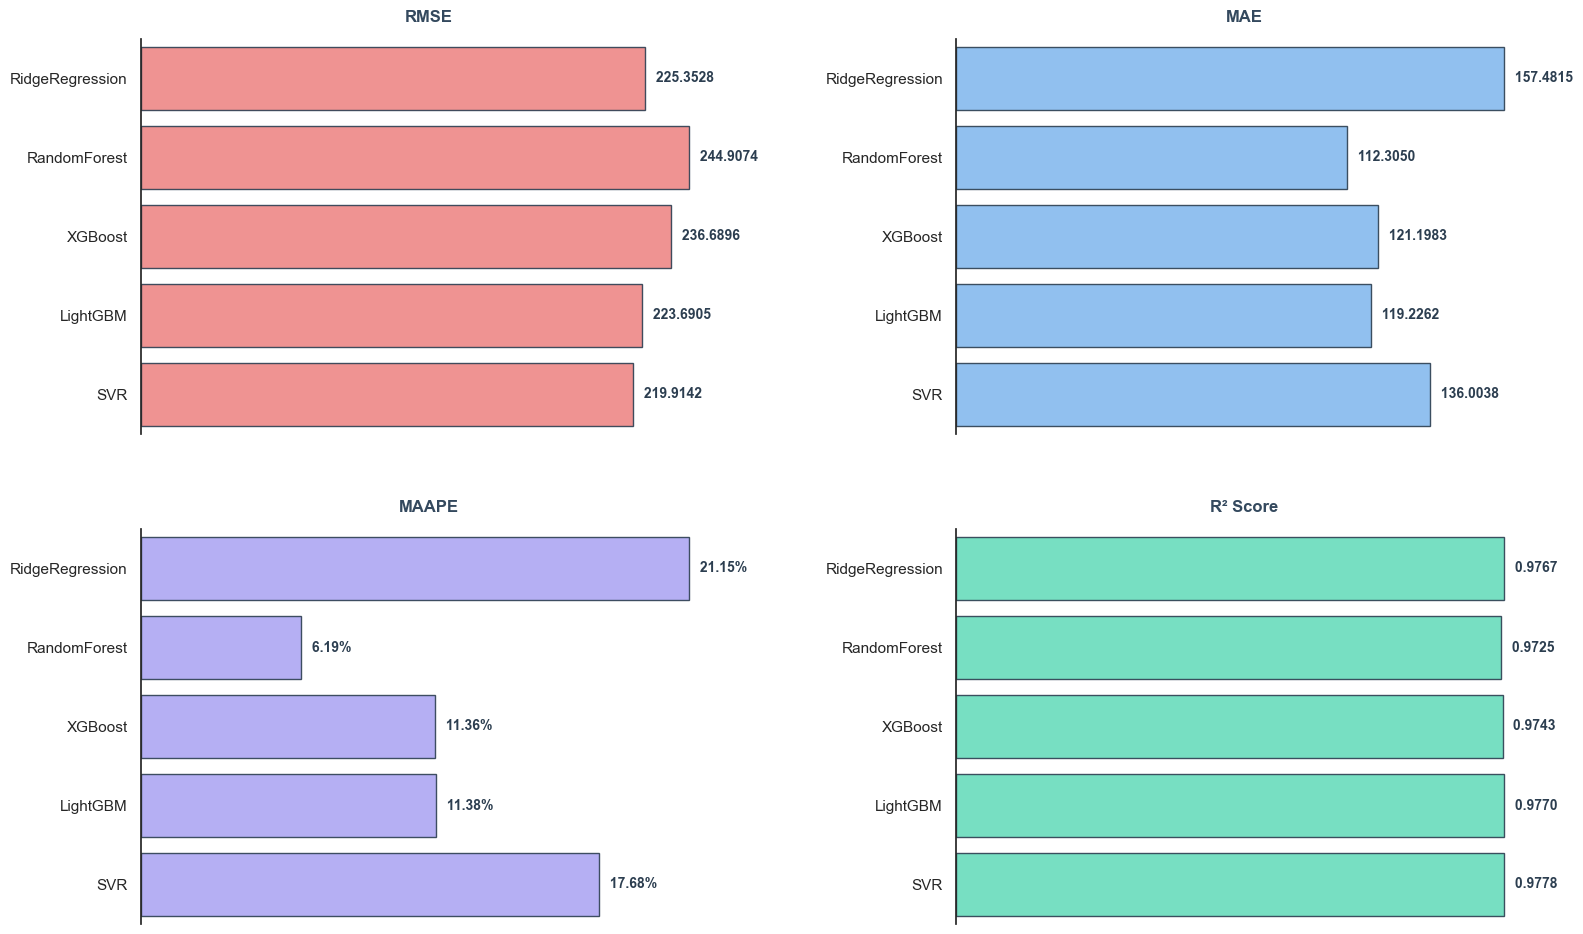

In [5]:

# --- TWEAK ESTETIKA ---
# Set tema dasar yang bersih
sns.set_theme(style="white") 
plt.rcParams['font.family'] = 'sans-serif'

# Buat kanvas grafik (2 Baris, 2 Kolom)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Definisi metrik dengan warna pastel yang adem di mata
metrics = [
    {'column': 'RMSE', 'title': 'RMSE', 'color': '#ff7675'}, # Pastel Merah
    {'column': 'MAE', 'title': 'MAE', 'color': '#74b9ff'},  # Pastel Biru
    {'column': 'MAAPE (%)', 'title': 'MAAPE', 'color': '#a29bfe'}, # Pastel Ungu
    {'column': 'R2', 'title': 'R² Score', 'color': '#55efc4'}  # Pastel Hijau
]

for i, met in enumerate(metrics):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Kita balik jadi HORIZONTAL (x dan y ditukar) biar gak menonjol kaku dan teksnya rapi
    sns.barplot(
        x=met['column'],
        y='Model',
        data=df_result_summary,
        ax=ax,
        hue='Model',
        palette=[met['color']],
        legend=False,
        alpha=0.9,
        edgecolor='#2c3e50', # Garis tepi tipis warna gelap biar tegas
        linewidth=1
    )
    
    # Tambahkan angka presisi di ujung setiap batang horizontal
    for p in ax.patches:
        width = p.get_width()
        if met['column'] == 'MAAPE (%)':
            label_text = f' {width:.2f}%'
        else:
            label_text = f' {width:.4f}'
        
        # Posisi teks di ujung kanan batang
        ax.annotate(
            label_text,
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center',
            xytext=(5, 0), 
            textcoords='offset points',
            fontsize=10, 
            fontweight='semibold',
            color='#2c3e50'
        )
    
    # Hapus garis box (top, right, bottom) biar clean ala infografis modern
    sns.despine(ax=ax, left=False, bottom=True, top=True, right=True)
    
    # Kustomisasi judul & label
    ax.set_title(met['title'], fontsize=12, fontweight='bold', color='#34495e', pad=12)
    ax.set_xlabel('') # Hapus label x karena angka sudah ada di ujung batang
    ax.set_ylabel('') # Hapus label y biar gak double sama nama model
    ax.set_xticklabels([]) # Hapus angka di sumbu bawah biar gak menumpuk
    ax.xaxis.grid(False) # Matikan garis grid vertikal
    ax.yaxis.grid(False) # Matikan garis grid horizontal

# Atur jarak biar gak saling tabrakan
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=4, w_pad=4)

# Tampilkan hasil yang jauh lebih glowing
plt.show()

C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\500080906.py:28: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\500080906.py:28: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\500080906.py:28: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\User KBJ 14\AppData\Local\Temp\ipykernel_29080\500080906.py:28: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


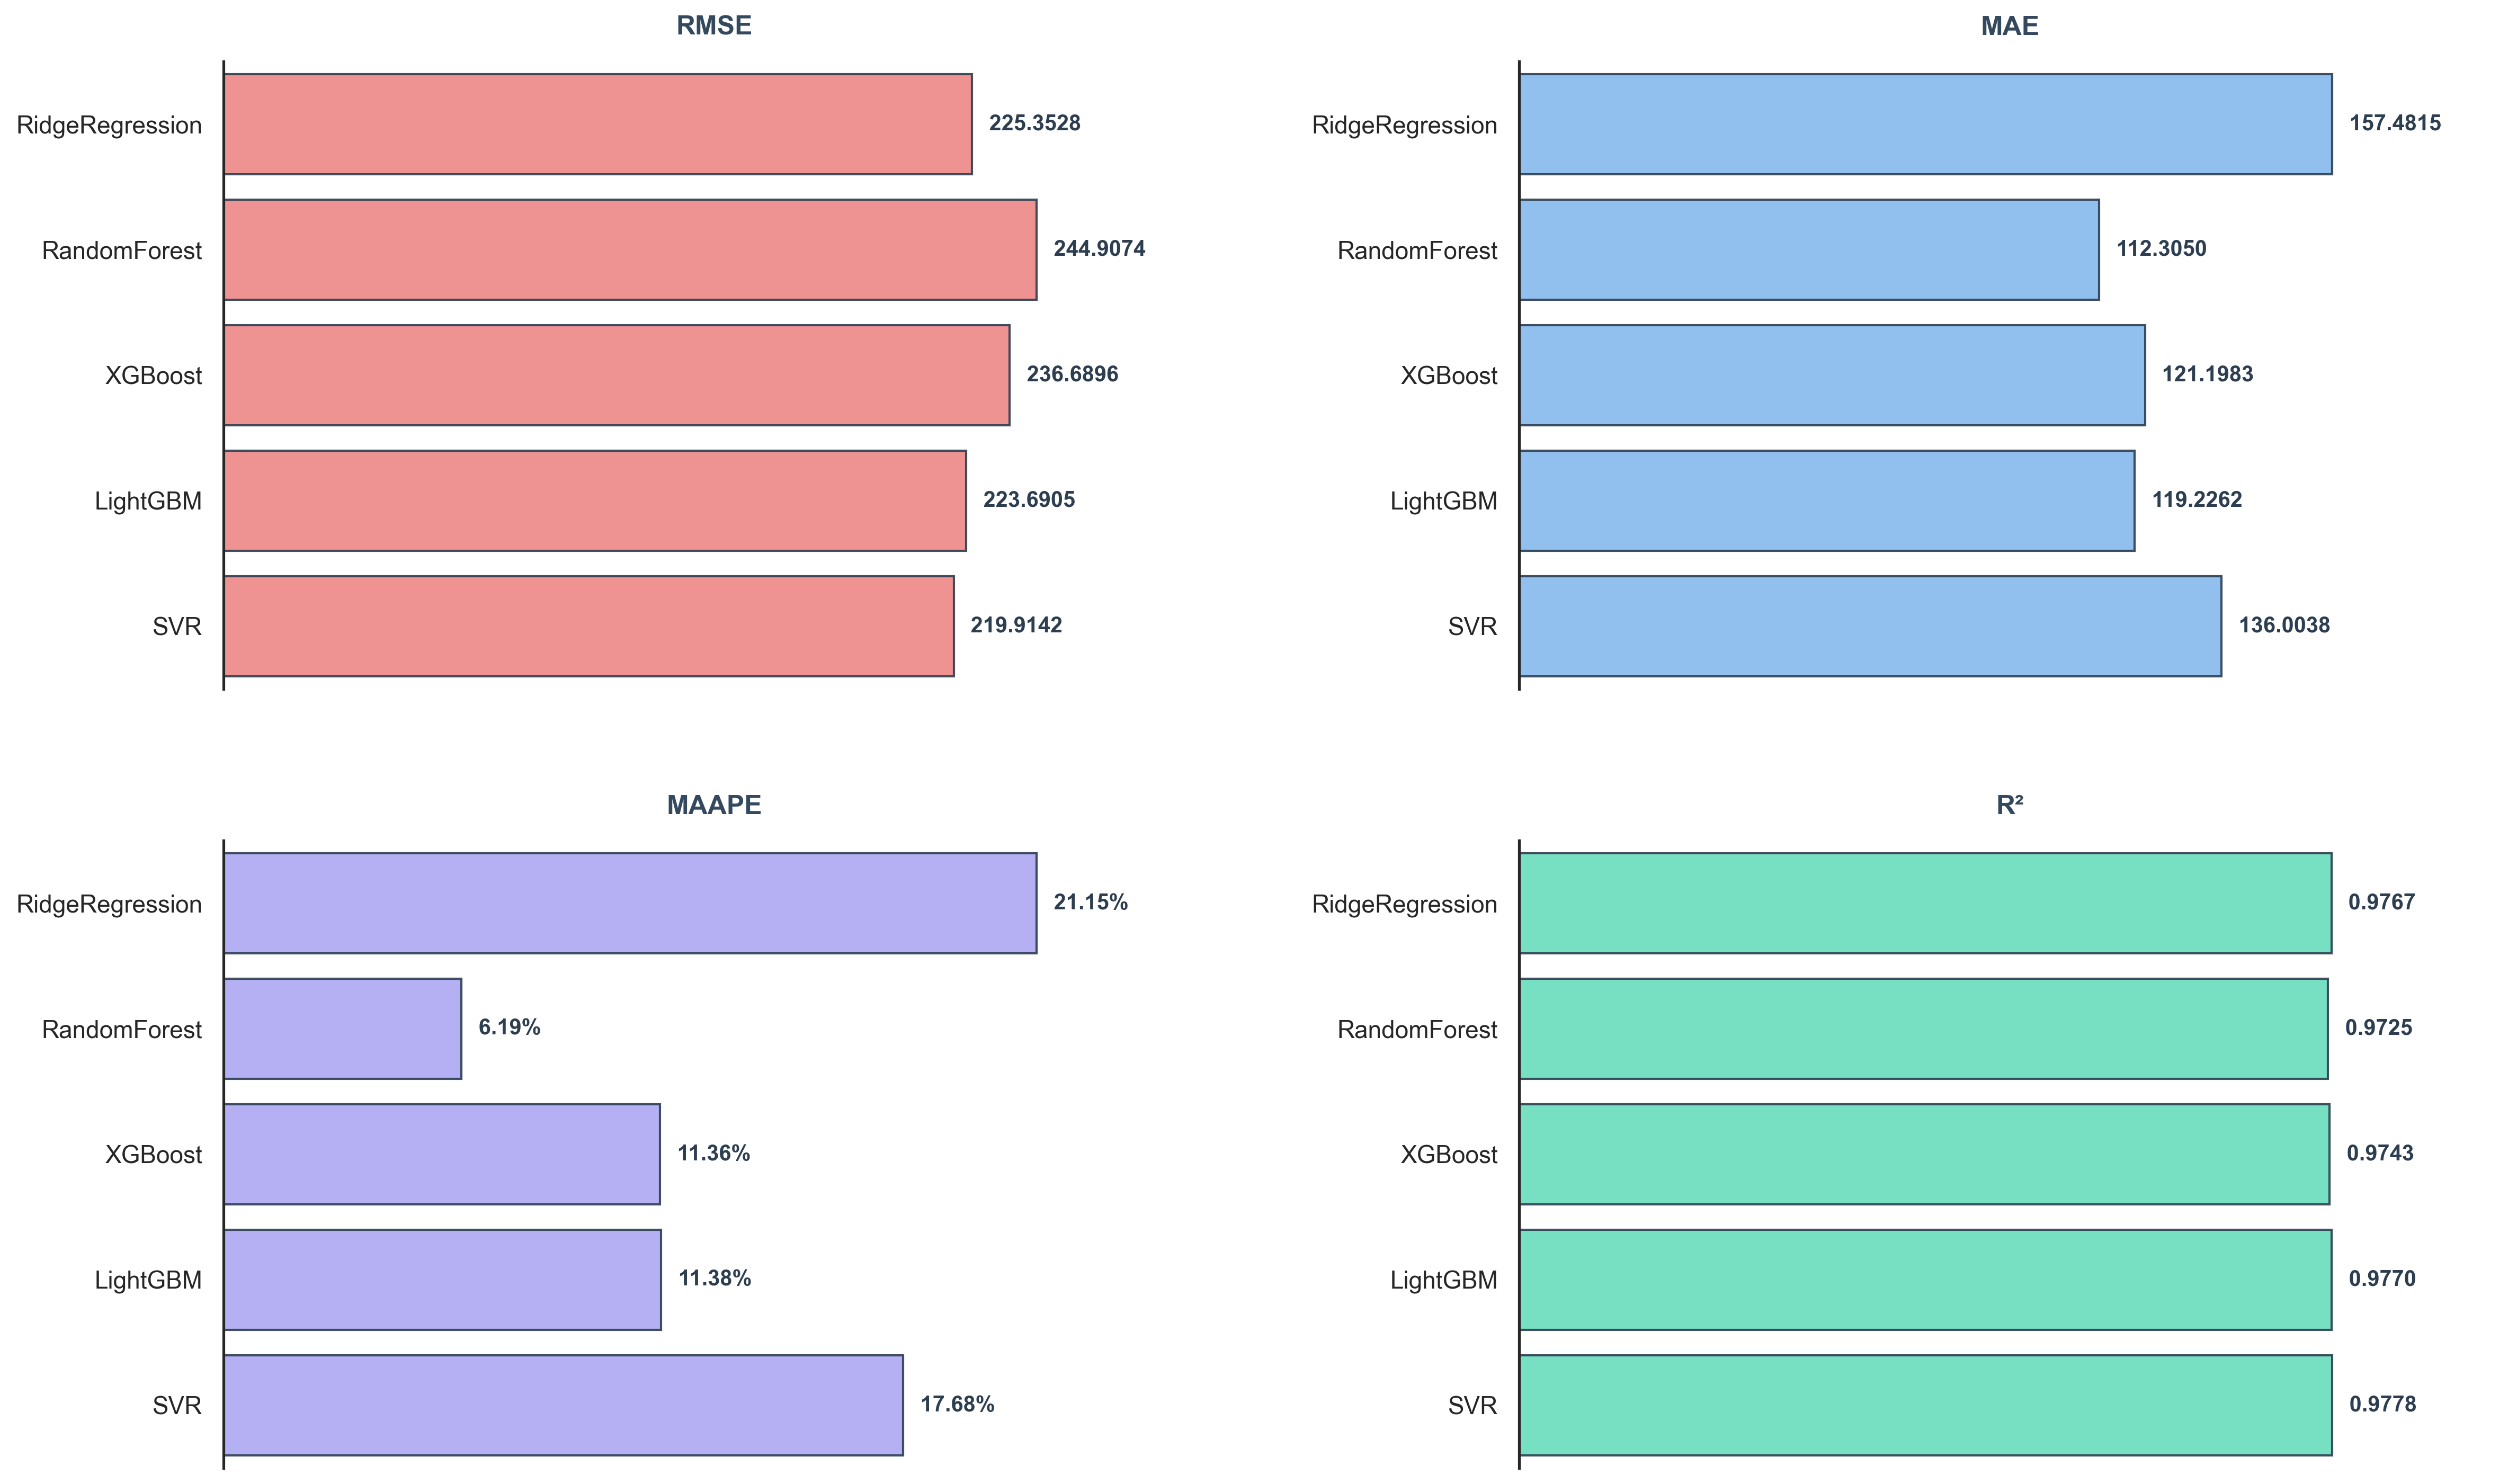

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- TWEAK ESTETIKA ---
sns.set_theme(style="white") 
plt.rcParams['font.family'] = 'sans-serif'

# 🌟 FIX 1: Set DPI global sebelum membuat grafik agar teks & garis sangat tajam (Crisp)
plt.rcParams['figure.dpi'] = 300 
plt.rcParams['savefig.dpi'] = 300 

# Buat kanvas grafik (2 Baris, 2 Kolom)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Definisi metrik dengan warna pastel
metrics = [
    {'column': 'RMSE', 'title': 'RMSE', 'color': '#ff7675'}, 
    {'column': 'MAE', 'title': 'MAE', 'color': '#74b9ff'},  
    {'column': 'MAAPE (%)', 'title': 'MAAPE', 'color': '#a29bfe'}, 
    {'column': 'R2', 'title': 'R²', 'color': '#55efc4'}  
]

for i, met in enumerate(metrics):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    sns.barplot(
        x=met['column'],
        y='Model',
        data=df_result_summary,
        ax=ax,
        hue='Model',
        palette=[met['color']],
        legend=False,
        alpha=0.9,
        edgecolor='#2c3e50', 
        linewidth=1
    )
    
    # Tambahkan angka presisi di ujung setiap batang horizontal
    for p in ax.patches:
        width = p.get_width()
        if met['column'] == 'MAAPE (%)':
            label_text = f' {width:.2f}%'
        else:
            label_text = f' {width:.4f}'
        
        ax.annotate(
            label_text,
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', 
            va='center',
            xytext=(5, 0), 
            textcoords='offset points',
            fontsize=10, 
            fontweight='semibold',
            color='#2c3e50'
        )
    
    # Hapus garis box biar clean
    sns.despine(ax=ax, left=False, bottom=True, top=True, right=True)
    
    # Kustomisasi judul & label
    ax.set_title(met['title'], fontsize=12, fontweight='bold', color='#34495e', pad=12)
    ax.set_xlabel('') 
    ax.set_ylabel('') 
    
    # 🌟 FIX 2: Memberikan padding otomatis di sisi kanan sumbu X sebesar 15% 
    # agar teks angka di ujung batang memiliki ruang dan tidak terpotong kanvas
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)
    
    # Menghilangkan penanda sumbu secara total dan bersih
    ax.get_xaxis().set_visible(False) 

# Atur jarak biar gak saling tabrakan
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=4, w_pad=4)

# 🌟 FIX 3: Cara menyimpan grafik dengan kualitas resolusi tinggi untuk Laporan/Paper Anda
# Gunakan format .png dengan bbox_inches='tight' agar potongan margin pas.
# plt.savefig('ringkasan_performa_model.png', dpi=300, bbox_inches='tight')

# Tampilkan hasil yang jauh lebih glowing dan tajam
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../Logs/grafik/evaluasi_harian_mencolok.png'

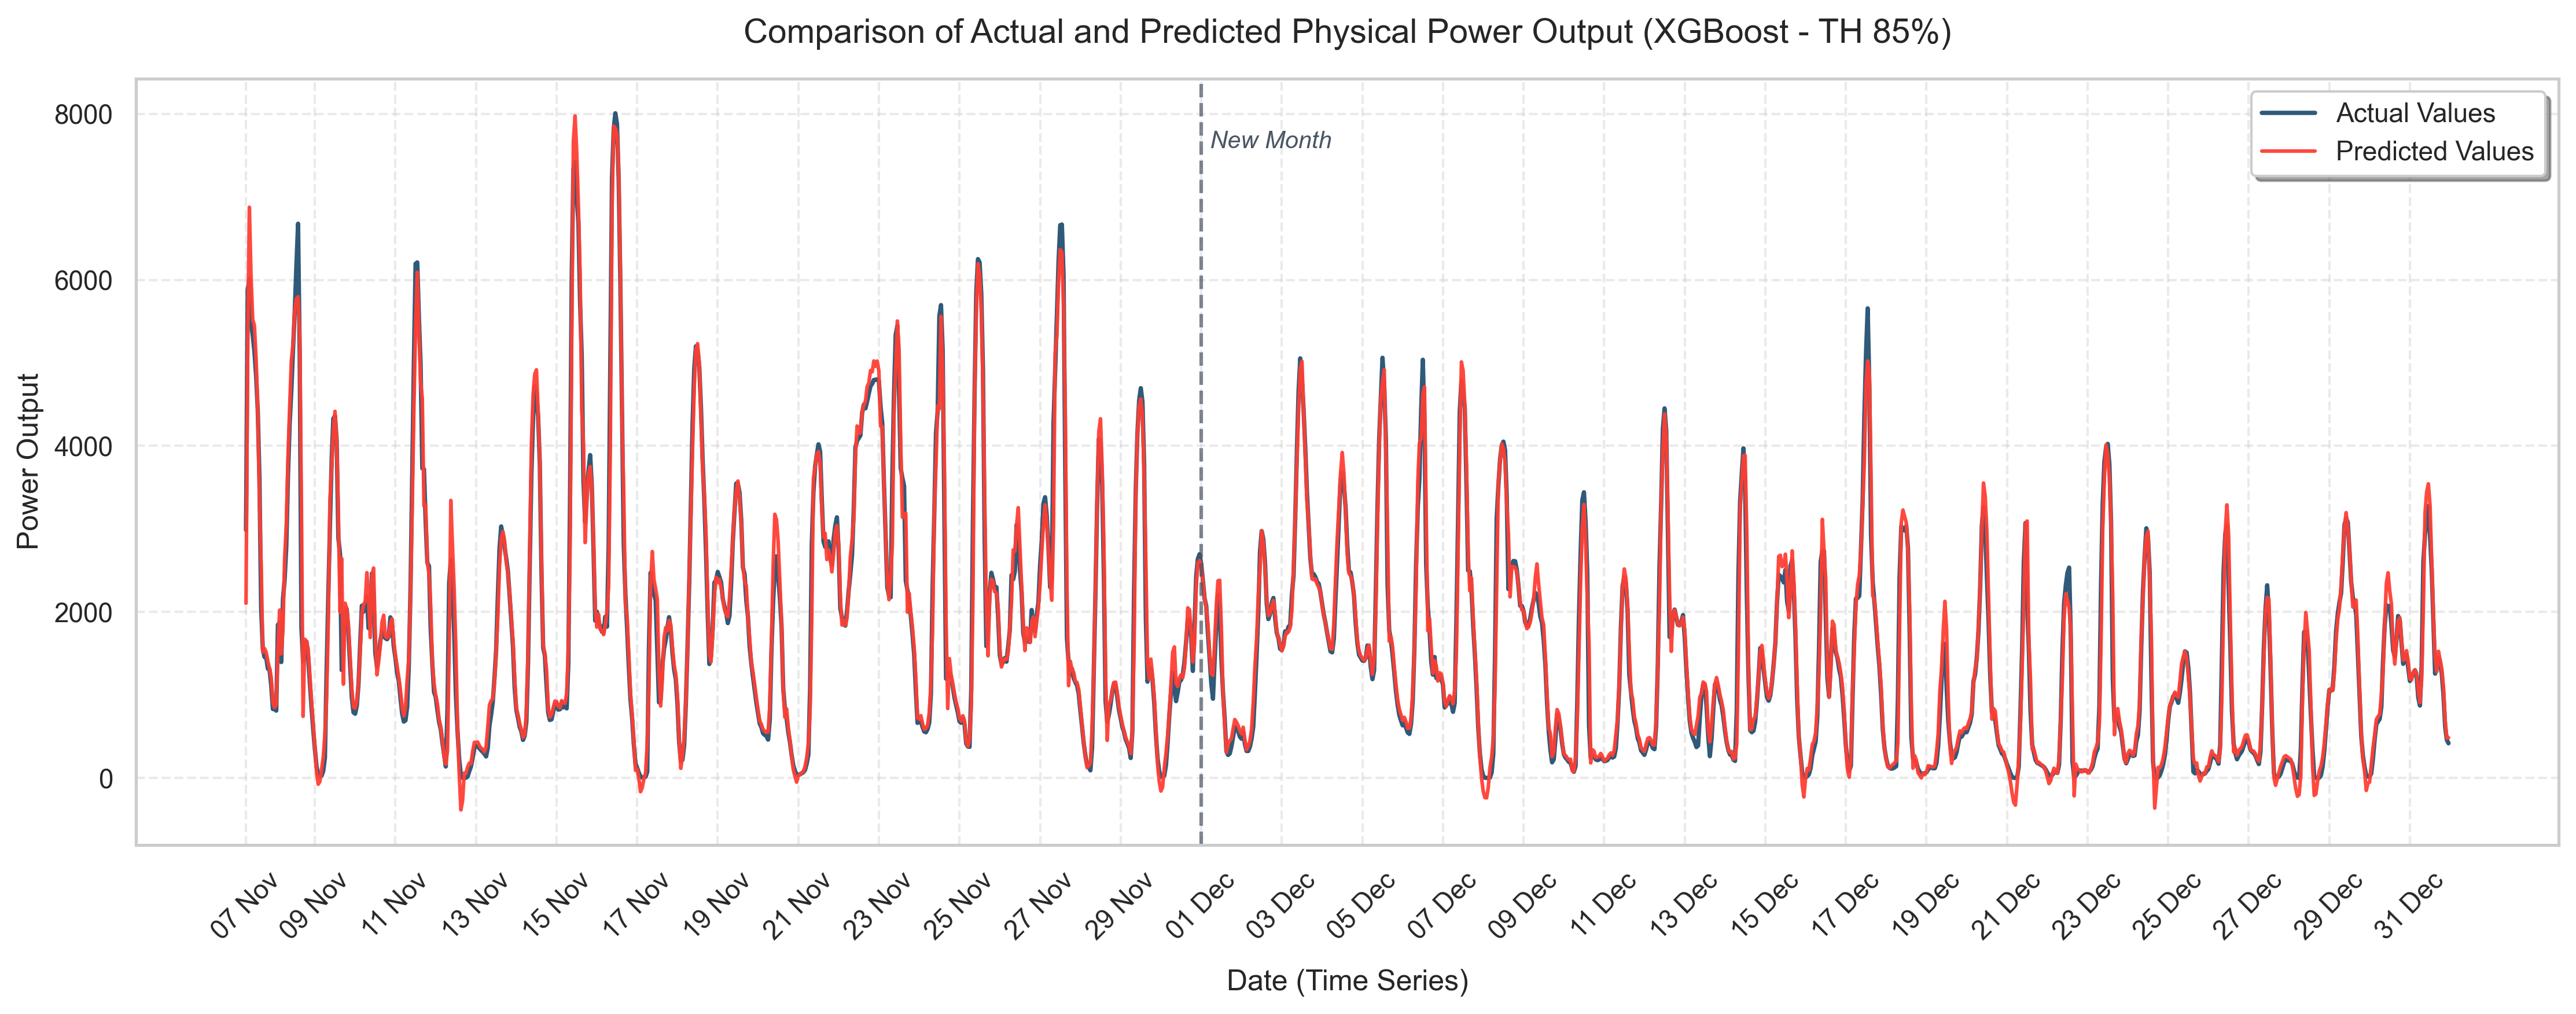

In [7]:
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])
df_test['date'] = df_test['timestamp'].dt.date

df_daily_first = df_test.drop_duplicates(subset=['date'])
idx_daily = [df_test.index.get_loc(idx) for idx in df_daily_first.index]

labels_daily = df_daily_first['timestamp'].dt.strftime('%d %b').values

ganti_bulan = df_test['timestamp'].dt.month.diff() != 0
idx_ganti_bulan = [df_test.index.get_loc(idx) for idx in df_test.index[ganti_bulan] if idx != df_test.index[0]]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12, 
    'axes.labelsize': 13, 
    'axes.titlesize': 14, 
    'xtick.labelsize': 11, 
    'ytick.labelsize': 11
})

plt.figure(figsize=(15, 6))

plt.plot(range(len(y_test)), y_test, label='Actual Values', color='#0a3d62', linewidth=1.8, alpha=0.85)
plt.plot(range(len(y_test)), preds, label='Predicted Values', color='#ff3f34', linewidth=1.5, alpha=0.95)

step = 2 
plt.xticks(ticks=np.array(idx_daily)[::step], labels=labels_daily[::step], rotation=45)

plt.title(f"Comparison of Actual and Predicted Physical Power Output (XGBoost - TH 85%)", fontsize=14, pad=15)
plt.xlabel("Date (Time Series)", fontsize=12, labelpad=10) 
plt.ylabel("Power Output", fontsize=12)

for idx in idx_ganti_bulan:
    plt.axvline(x=idx, color='#4b5563', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(idx + 5, plt.gca().get_ylim()[1] * 0.9, 'New Month', color='#4b5563', fontsize=10, style='italic')

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig('../Logs/grafik/evaluasi_harian_mencolok.png', dpi=300, bbox_inches='tight')
plt.show()

[SUKSES] Grafik Absolute Error format harian berhasil dibuat!


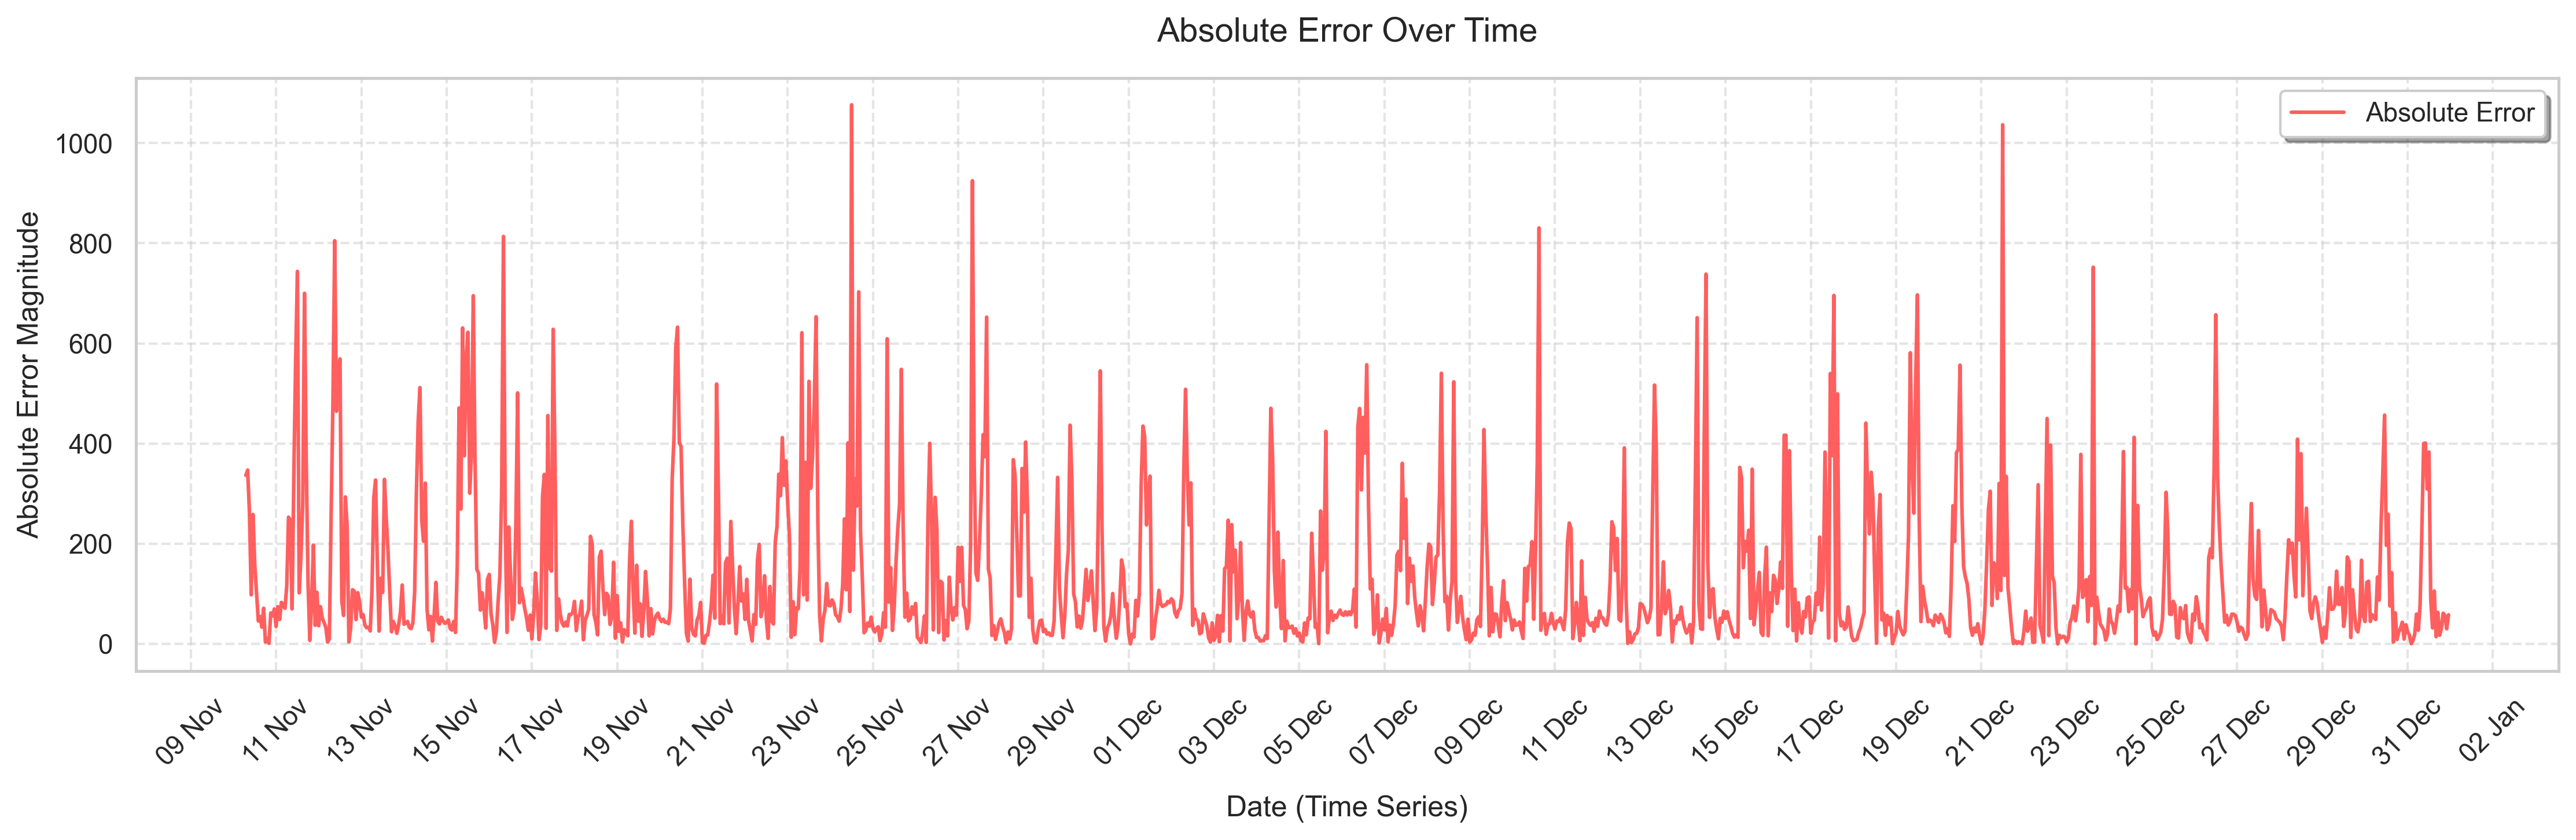

In [ ]:
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])
absolute_error = np.abs(y_test - preds)

plt.figure(figsize=(15, 5))
test_timestamps = df_test['timestamp']

plt.plot(
    test_timestamps, 
    absolute_error, 
    label='Absolute Error', 
    color='#ff4d4d', 
    linewidth=1.5, 
    alpha=0.9
)

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) 

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

plt.xticks(rotation=45)

plt.title(f"Absolute Error Over Time", fontsize=14, pad=15)
plt.xlabel("Date (Time Series)", fontsize=12, labelpad=10)
plt.ylabel("Absolute Error Magnitude", fontsize=12)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True, facecolor='white')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('../Logs/grafik/evaluasi_absolute_error_harian.png', dpi=300, bbox_inches='tight')
print("[SUKSES] Grafik Absolute Error format harian berhasil dibuat!")

plt.show()